In [ ]:
# !pip install sentence-transformers scikit-learn numpy matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------------------- ---------------- 4.7/8.1 MB 23.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 24.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.5 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
"Me gusta la inteligencia artificial",
"La IA es fascinante",
"Ayer comí pizza",
"El pepperoni es mi topping favorito"
]

embeddings = model.encode(sentences)

print("Shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape: (4, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

for i, s in enumerate(sentences):
    print(s)
    print(similarity_matrix[i])
    print("---")

Me gusta la inteligencia artificial
[0.9999999  0.46773177 0.29849744 0.39839768]
---
La IA es fascinante
[0.46773177 0.9999996  0.23412251 0.4279822 ]
---
Ayer comí pizza
[0.29849744 0.23412251 1.0000001  0.4451853 ]
---
El pepperoni es mi topping favorito
[0.39839768 0.4279822  0.4451853  1.        ]
---


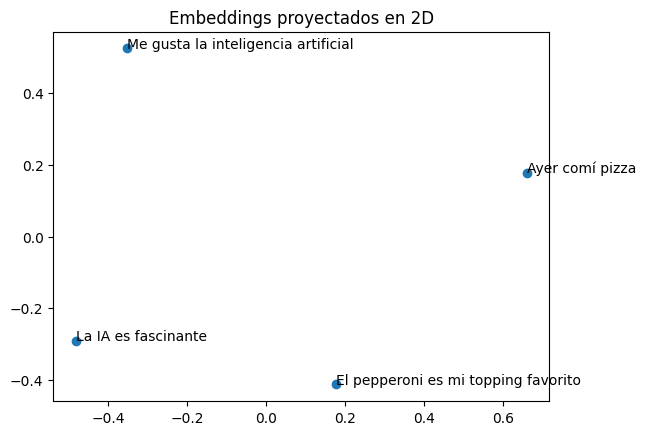

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure()
plt.scatter(reduced[:,0], reduced[:,1])

for i, txt in enumerate(sentences):
    plt.annotate(txt, (reduced[i,0], reduced[i,1]))

plt.title("Embeddings proyectados en 2D")
plt.show()

In [ ]:
docs = [
"No puedo conectarme a la VPN",
"Error al abrir correo Outlook",
"VPN caída, no hay acceso remoto",
"Problema con la impresora en oficina",
"Outlook muestra error al enviar correo"
]

doc_embeddings = model.encode(docs)

query = "No puedo acceder a la VPN desde casa"
query_emb = model.encode([query])

scores = cosine_similarity(query_emb, doc_embeddings)[0]

for doc, score in sorted(zip(docs, scores), key=lambda x: x[1], reverse=True):
    print(f"{score:.3f} → {doc}")

0.857 → No puedo conectarme a la VPN
0.667 → VPN caída, no hay acceso remoto
0.425 → Problema con la impresora en oficina
0.317 → Outlook muestra error al enviar correo
0.284 → Error al abrir correo Outlook
